# Digit Recognizer (Kaggle)

## Setup

Imports and device selection (CUDA if available).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

print('PyTorch version:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

PyTorch version: 2.8.0+cu126
Device: cuda


## Data Preparation

Load `train.csv`, split 80/20 (stratified) into train/validation, and reshape into `(1, 28, 28)` image tensors.

In [2]:
class AugmentedDataset(Dataset):
    def __init__(self, x_tensor, y_tensor, transform=None):
        self.x = x_tensor
        self.y = y_tensor
        self.transform = transform

    def __getitem__(self, index):
        img = self.x[index]
        label = self.y[index]
        
        # Apply random augmentations on the fly if specified
        if self.transform:
            img = self.transform(img)
            
        return img, label

    def __len__(self):
        return len(self.x)

In [3]:
divide = 255

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

def dilate(x, kernel_size=3):
    return F.max_pool2d(x, kernel_size, stride=1, padding=kernel_size//2)

def erode(x, kernel_size=3):
    return -F.max_pool2d(-x, kernel_size, stride=1, padding=kernel_size//2)

df = pd.read_csv('train.csv')
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

X_train_t = torch.tensor(X_train, dtype=torch.float32) / divide
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32) / divide
y_test_t = torch.tensor(y_test, dtype=torch.long)

X_train_t = X_train_t.view(-1, 1, 28, 28)
X_test_t = X_test_t.view(-1, 1, 28, 28)

rotate_left  = transforms.RandomRotation(degrees=(-4, -4)) 
rotate_right = transforms.RandomRotation(degrees=(4, 4))   
shear_left  = transforms.RandomAffine(degrees=0, shear=(-10, -10))
shear_right = transforms.RandomAffine(degrees=0, shear=(10, 10))
elastic = transforms.ElasticTransform(alpha=34.0, sigma=4.0)

stretch_horiz = transforms.Compose([
    transforms.Resize((28, 32)), 
    transforms.CenterCrop(28)
])

stretch_vert = transforms.Compose([
    transforms.Resize((32, 28)), 
    transforms.CenterCrop(28)
])

X_rot_left    = rotate_left(X_train_t)
X_rot_right   = rotate_right(X_train_t)
X_str_horiz   = stretch_horiz(X_train_t)
X_str_vert    = stretch_vert(X_train_t)
X_elastic     = elastic(X_train_t)
X_shear_right = shear_right(X_train_t)
X_shear_left  = shear_left(X_train_t)
X_thick = dilate(X_train_t)
X_thin  = erode(X_train_t)


X_train_expanded = torch.cat([X_train_t, X_rot_left, X_rot_right, X_str_horiz, X_str_vert, X_elastic, X_shear_right, X_shear_left, X_thick, X_thin], dim=0)
y_train_expanded = torch.cat([y_train_t, y_train_t, y_train_t, y_train_t, y_train_t, y_train_t, y_train_t, y_train_t, y_train_t, y_train_t], dim=0)

print(f"Original training size: {X_train_t.size(0)}")
print(f"Expanded training size: {X_train_expanded.size(0)}")

train_dataset = TensorDataset(X_train_expanded, y_train_expanded)
test_dataset  = TensorDataset(X_test_t, y_test_t) 

# 7. Fast DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

Original training size: 37800
Expanded training size: 378000


## Model Architecture

3-block CNN (Conv3x3 → BatchNorm → ReLU, doubled per block) with global average pooling and a dropout classifier head.

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(p=0.5),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(p=0.5),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), 
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), 
            nn.ReLU(),
            nn.Dropout(p=0.5),
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x) ##
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

## Training

AdamW + `ReduceLROnPlateau`, with early stopping and checkpointing the best-val-loss model to `CNN.pt`.

Epoch 1: train=0.7455  val=0.5654  acc=0.9948 lr=0.001000 improved
Epoch 2: train=0.6494  val=0.5444  acc=0.9945 lr=0.001000 improved
Epoch 3: train=0.6331  val=0.5386  acc=0.9960 lr=0.001000 improved
Epoch 4: train=0.6242  val=0.5336  acc=0.9960 lr=0.001000 improved
Epoch 5: train=0.6186  val=0.5259  acc=0.9952 lr=0.001000 improved
Epoch 6: train=0.6111  val=0.5238  acc=0.9955 lr=0.001000 improved
Epoch 7: train=0.6059  val=0.5189  acc=0.9955 lr=0.001000 improved
Epoch 8: train=0.6033  val=0.5197  acc=0.9964 lr=0.001000 no improvement (1/5)
Epoch 9: train=0.6016  val=0.5166  acc=0.9969 lr=0.001000 improved
Epoch 10: train=0.6001  val=0.5170  acc=0.9960 lr=0.001000 no improvement (1/5)
Epoch 11: train=0.5992  val=0.5176  acc=0.9960 lr=0.000500 no improvement (2/5)
Epoch 12: train=0.5947  val=0.5148  acc=0.9967 lr=0.000500 improved
Epoch 13: train=0.5929  val=0.5143  acc=0.9971 lr=0.000500 improved
Epoch 14: train=0.5917  val=0.5155  acc=0.9969 lr=0.000500 no improvement (1/5)
Epoch 15:

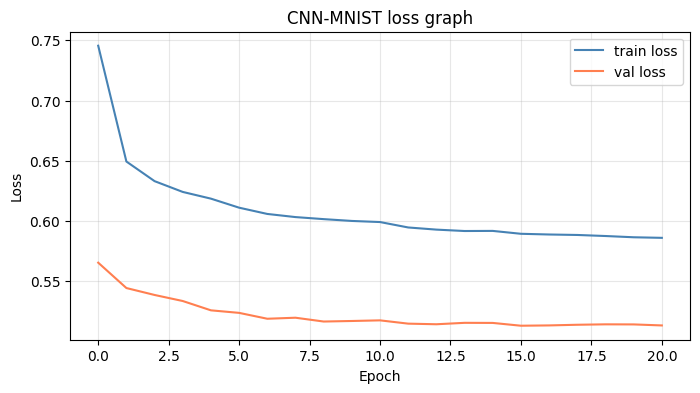

In [6]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

model = CNN().to(device)

criterion     = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer     = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

train_losses = []
val_losses   = []
lr_history   = []

best_val_loss = float('inf')
final_acc     = 0
patience      = 5              
no_improve    = 0

for epoch in range(50):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    correct, total = 0, 0
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            batch_val.append(criterion(pred, y_batch).item())
            correct += (torch.argmax(pred, 1) == y_batch).sum().item()
            total   += y_batch.size(0)
    val_loss = np.mean(batch_val)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        final_acc = correct / total * 100
        print(f'Epoch {epoch+1}: train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  acc={correct/total:.4f} lr={current_lr:.6f} improved')
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'input_dim': 28,
            'model_name': 'CNN',
        }
        torch.save(checkpoint, 'CNN.pt')
    else:
        no_improve += 1
        print(f'Epoch {epoch+1}: train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  acc={correct/total:.4f} lr={current_lr:.6f} no improvement ({no_improve}/{patience})')

    if no_improve >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break 

print(f'\nFinal accuracy from CNN: {final_acc:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'steelblue', label='train loss')
plt.plot(val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'CNN-MNIST loss graph')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Error Analysis

Run the best checkpoint over the held-out validation set, find the misclassified images, and display the ones the model was most confidently wrong about.

Total validation errors: 14 / 4200


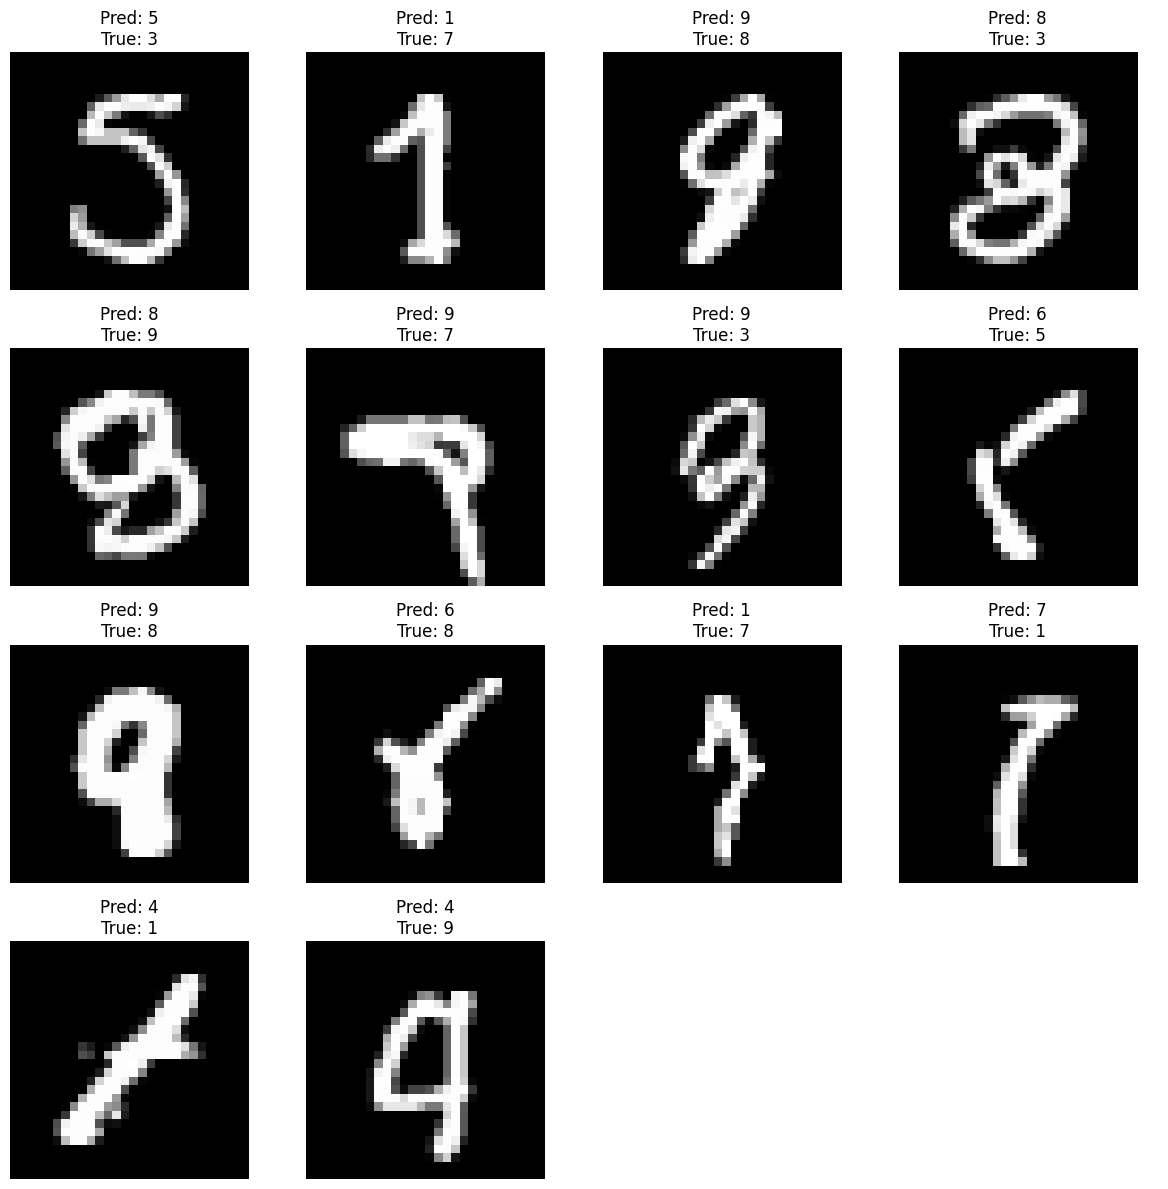

In [ ]:
checkpoint     = torch.load('CNN.pt', weights_only=False, map_location=device)
eval_model     = CNN().to(device)
eval_model.load_state_dict(checkpoint['model_state_dict'])
eval_model.eval()

with torch.no_grad():
    probs = F.softmax(eval_model(X_test_t.to(device)), dim=1).cpu()

pred_classes = torch.argmax(probs, dim=1)
true_classes = y_test_t

errors_mask = pred_classes != true_classes
error_idx   = errors_mask.nonzero(as_tuple=True)[0]

pred_prob_errors = probs[error_idx, pred_classes[error_idx]]
true_prob_errors = probs[error_idx, true_classes[error_idx]]

confidence_gap = pred_prob_errors - true_prob_errors
all_errors     = error_idx[torch.argsort(confidence_gap, descending=True)]

print(f'Total validation errors: {len(error_idx)} / {len(true_classes)}')

n_cols = 4
n_rows = int(np.ceil(len(all_errors) / n_cols))
fig, ax = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
ax = ax.flatten()
for i, idx in enumerate(all_errors):
    ax[i].imshow(X_test_t[idx, 0], cmap='gray')
    ax[i].set_title(f'Pred: {pred_classes[idx].item()}\nTrue: {true_classes[idx].item()}')
    ax[i].axis('off')
for i in range(len(all_errors), len(ax)):
    ax[i].axis('off')
plt.tight_layout()
plt.show()

## Kaggle Inference & Submission

Reload the best checkpoint, run it over `test.csv`, and write predictions to `submission.csv`.

In [19]:
test_df = pd.read_csv('test.csv')
X_kaggle = test_df.values
X_kaggle_t = torch.tensor(X_kaggle, dtype=torch.float32) / divide
X_kaggle_t = X_kaggle_t.view(-1, 1, 28, 28)
kaggle_test_loader = DataLoader(X_kaggle_t, batch_size=64, shuffle=False)

checkpoint      = torch.load('CNN.pt', weights_only=False, map_location=device)
final_cnn_model = CNN().to(device)
final_cnn_model.load_state_dict(checkpoint['model_state_dict']) 
final_cnn_model.eval()
kaggle_preds = []

with torch.no_grad():
    for X_batch in kaggle_test_loader:
        X_batch = X_batch.to(device)
        outputs = final_cnn_model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        kaggle_preds.extend(preds.cpu().tolist())


submission = pd.DataFrame({
    'ImageId': range(1, len(kaggle_preds) + 1),
    'Label': kaggle_preds
})

# 6. Save out to CSV
submission.to_csv('submission.csv', index=False)

## Test-Time Augmentation (TTA) Inference

Run the same checkpoint over several slightly-perturbed versions of each test image and average the softmax probabilities, instead of predicting from a single unmodified pass.

In [ ]:
import torch.nn.functional as F

test_df = pd.read_csv('test.csv')
X_kaggle_t = (torch.tensor(test_df.values, dtype=torch.float32) / divide).view(-1, 1, 28, 28)
kaggle_test_loader = DataLoader(X_kaggle_t, batch_size=64, shuffle=False)

checkpoint      = torch.load('CNN.pt', weights_only=False, map_location=device)
final_cnn_model = CNN().to(device)
final_cnn_model.load_state_dict(checkpoint['model_state_dict'])
final_cnn_model.eval()

tta_transforms = [
    None,
    transforms.RandomRotation(degrees=(-5, -5)),
    transforms.RandomRotation(degrees=(5, 5)),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.RandomAffine(degrees=0, scale=(0.95, 0.95)),
    transforms.RandomAffine(degrees=0, shear=(-10, -10)),
    transforms.RandomAffine(degrees=0, shear=(10, 10)),
    dilate,
    erode
]

all_probs = None
with torch.no_grad():
    for tta in tta_transforms:
        pass_probs = []
        for X_batch in kaggle_test_loader:
            if tta is not None:
                X_batch = tta(X_batch)
            X_batch = X_batch.to(device)
            probs = F.softmax(final_cnn_model(X_batch), dim=1)
            pass_probs.append(probs.cpu())
        pass_probs = torch.cat(pass_probs, dim=0)
        all_probs = pass_probs if all_probs is None else all_probs + pass_probs

final_preds = torch.argmax(all_probs, dim=1).tolist()

submission = pd.DataFrame({
    'ImageId': range(1, len(final_preds) + 1),
    'Label': final_preds
})

submission.to_csv('submission.csv', index=False)